# Crypto Perpetual Funding Carry Jupyter Notebook

This notebook is the research backing and companion of the "Crypto Perpetual Funding Carry" paper by Mossab Alsadig.

The project flow is: load the market data, align it to funding events, define the backtest engine, run the fixed final rule, review in-sample and forward results, run diagnostics, and then produce the reporting charts one at a time.

## 0. Setup

Start with imports, project paths, and the final rule parameters. The path finder lets the notebook run from the project folder or from this notebook's subfolder.


In [144]:
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.options.display.float_format = '{:,.4f}'.format
pd.options.display.max_columns = 50

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'selected_universe.csv').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Could not find data/selected_universe.csv. Run from the project folder or a subfolder.')

DATA = ROOT / 'data'
OUTPUT = ROOT / 'output'
CHARTS = OUTPUT / 'charts'
CHARTS.mkdir(parents=True, exist_ok=True)

EVENTS_PER_YEAR = 365 * 3
TRAIN_END = '2023-12-31 23:59:59'
FORWARD_START = '2024-01-01'
COST = 0.0020

FINAL_LOOKBACK = 126
FINAL_HORIZON = 14
FINAL_ENTRY = 0.00025

pd.Series({
    'events_per_year': EVENTS_PER_YEAR,
    'train_end': TRAIN_END,
    'forward_start': FORWARD_START,
    'cost_per_turnover': COST,
    'final_lookback_events': FINAL_LOOKBACK,
    'final_basis_horizon_events': FINAL_HORIZON,
    'final_entry_threshold': FINAL_ENTRY,
})

events_per_year                              1095
train_end                     2023-12-31 23:59:59
forward_start                          2024-01-01
cost_per_turnover                          0.0020
final_lookback_events                         126
final_basis_horizon_events                     14
final_entry_threshold                      0.0003
dtype: object

## 1. Load And Align The Data

The selected universe defines the columns used across every panel. Each panel is sorted by timestamp, restricted to the selected symbols, and coerced to numeric values.


In [145]:
selected = pd.read_csv(DATA / 'selected_universe.csv')
symbols = selected['base_asset'].astype(str).tolist()

selected

,selected_order,base_asset,futures_symbol,spot_symbol,selection_window,coverage_window_start,coverage_window_end,coverage_window_hourly_rows,coverage_window_funding_events,spot_close_coverage,perp_close_coverage,mark_close_coverage,premium_close_coverage,funding_event_coverage,median_train_hourly_perp_quote_volume,total_train_perp_quote_volume,passes_filters,fail_reasons,current_survivor_caveat
0,1,BTC,BTCUSDT,BTCUSDT,train_2020_2023,2020-01-01T00:00:00,2023-12-31T23:00:00,35064,4383,0.9991,1.0000,0.9945,0.9952,1.0000,"320,244,752.4792","16,424,925,234,319.3125",True,NaN,current-survivor research panel
1,2,ETH,ETHUSDT,ETHUSDT,train_2020_2023,2020-01-01T00:00:00,2023-12-31T23:00:00,35064,4383,0.9991,1.0000,0.9986,0.9952,1.0000,"152,370,611.6076","7,816,785,055,680.0264",True,NaN,current-survivor research panel
2,3,SOL,SOLUSDT,SOLUSDT,train_2020_2023,2020-09-14T07:00:00,2023-12-31T23:00:00,28889,3611,0.9993,0.9958,0.9942,0.9950,1.0000,"22,114,174.3700","1,150,835,539,771.6282",True,NaN,current-survivor research panel
3,4,XRP,XRPUSDT,XRPUSDT,train_2020_2023,2020-01-06T08:00:00,2023-12-31T23:00:00,34936,4367,0.9991,0.9966,0.9952,0.9958,1.0000,"16,781,910.6652","1,235,664,367,786.4058",True,NaN,current-survivor research panel
4,5,BNB,BNBUSDT,BNBUSDT,train_2020_2023,2020-02-10T08:00:00,2023-12-31T23:00:00,34096,4262,0.9991,1.0000,0.9944,0.9950,1.0000,"12,555,090.4848","884,732,219,225.8810",True,NaN,current-survivor research panel
5,6,DOGE,DOGEUSDT,DOGEUSDT,train_2020_2023,2020-07-10T09:00:00,2023-12-31T23:00:00,30471,3808,0.9994,1.0000,0.9984,0.9945,1.0000,"11,598,827.1918","965,008,896,913.7791",True,NaN,current-survivor research panel
6,7,ADA,ADAUSDT,ADAUSDT,train_2020_2023,2020-01-31T08:00:00,2023-12-31T23:00:00,34336,4292,0.9991,1.0000,0.9986,0.9951,1.0000,"10,622,630.9995","707,800,678,900.6743",True,NaN,current-survivor research panel
7,8,LINK,LINKUSDT,LINKUSDT,train_2020_2023,2020-01-17T08:00:00,2023-12-31T23:00:00,34672,4334,0.9991,1.0000,0.9945,0.9951,1.0000,"9,894,237.1631","503,453,922,030.1101",True,NaN,current-survivor research panel
8,9,DOT,DOTUSDT,DOTUSDT,train_2020_2023,2020-08-22T07:00:00,2023-12-31T23:00:00,29441,3680,0.9994,1.0000,0.9935,0.9943,1.0000,"9,071,077.8763","453,523,947,786.3747",True,NaN,current-survivor research panel
9,10,ARB,ARBUSDT,ARBUSDT,train_2020_2023,2023-03-23T07:00:00,2023-12-31T23:00:00,6809,851,0.9987,0.9988,0.9991,0.9988,1.0000,"8,718,617.6851","118,188,801,628.3373",True,NaN,current-survivor research panel


In [146]:
def read_panel(name):
    return (pd.read_csv(DATA / name, index_col=0, parse_dates=True)
              .sort_index()
              .loc[:, symbols]
              .apply(pd.to_numeric, errors='coerce'))

spot_close = read_panel('panel_spot_close_1h.csv')
perp_close = read_panel('panel_perp_close_1h.csv')
basis = read_panel('panel_basis_1h.csv')
funding = read_panel('panel_funding_rate_event.csv')

pd.DataFrame({
    'rows': [len(spot_close), len(perp_close), len(basis), len(funding)],
    'columns': [spot_close.shape[1], perp_close.shape[1], basis.shape[1], funding.shape[1]],
}, index=['spot_close', 'perp_close', 'basis', 'funding'])

,rows,columns
spot_close,56760,20
perp_close,56760,20
basis,56760,20
funding,7095,20


In [147]:
events = funding.dropna(how='all').index
funding = funding.reindex(events)

pd.Series({
    'first_funding_event': events.min(),
    'last_funding_event': events.max(),
    'n_funding_events': len(events),
})

first_funding_event    2020-01-01 00:00:00
last_funding_event     2026-06-22 08:00:00
n_funding_events                      7094
dtype: object

In [148]:
event_spot = spot_close.shift(1).reindex(events)
event_perp = perp_close.shift(1).reindex(events)
event_basis = basis.shift(1).reindex(events)

spot_ret = event_spot.pct_change(fill_method=None).replace([np.inf, -np.inf], np.nan)
perp_ret = event_perp.pct_change(fill_method=None).replace([np.inf, -np.inf], np.nan)

pd.DataFrame({
    'spot_return_non_null': spot_ret.notna().sum(),
    'perp_return_non_null': perp_ret.notna().sum(),
}).head()

,spot_return_non_null,perp_return_non_null
BTC,7084,7092
ETH,7084,7092
SOL,6417,6304
XRP,7084,7059
BNB,7084,6971


## 2. Backtest Engine

This cell defines the small pieces of the backtest. The key anti-lookahead convention is that signals use prior funding and prior basis, and weights are shifted one funding event before returns are calculated. The main method here is `run_rule` at the bottom, with it's helper functions above it.


In [149]:
def assemble_returns(spot_pnl, perp_pnl, funding_pnl, gross, spot_turnover, perp_turnover, turnover, exposure):
    valid_returns = spot_ret.notna().any(axis=1) | perp_ret.notna().any(axis=1)

    return pd.DataFrame({
        'gross_return': gross,
        'net_return_20bps': gross - COST * turnover,
        'spot_price_pnl': spot_pnl,
        'perp_price_pnl': perp_pnl,
        'funding_pnl': funding_pnl,
        'spot_turnover': spot_turnover,
        'perp_turnover': perp_turnover,
        'total_turnover': turnover,
        'gross_exposure': exposure,
    }).loc[valid_returns]

def compute_return_components(spot_weight, perp_weight):
    spot_pnl = (spot_weight * spot_ret.fillna(0.0)).sum(axis=1)
    perp_pnl = (perp_weight * perp_ret.fillna(0.0)).sum(axis=1)
    funding_pnl = -(perp_weight * funding.fillna(0.0)).sum(axis=1)
    gross = spot_pnl + perp_pnl + funding_pnl

    spot_turnover = spot_weight.diff().abs().sum(axis=1).fillna(0.0)
    perp_turnover = perp_weight.diff().abs().sum(axis=1).fillna(0.0)
    spot_turnover.iloc[0] = perp_turnover.iloc[0] = 0.0

    turnover = spot_turnover + perp_turnover
    exposure = spot_weight.abs().sum(axis=1) + perp_weight.abs().sum(axis=1)

    return spot_pnl, perp_pnl, funding_pnl, gross, spot_turnover, perp_turnover, turnover, exposure

def apply_execution_lag(spot_target, perp_target):
    spot_weight = spot_target.shift(1).reindex_like(spot_ret).fillna(0.0)
    perp_weight = perp_target.shift(1).reindex_like(perp_ret).fillna(0.0)
    return spot_weight, perp_weight

def build_target_weights(active):
    n_active = active.sum(axis=1).replace(0, np.nan)
    unit_weight = active.div(n_active, axis=0).fillna(0.0)
    spot_target = 0.5 * unit_weight
    perp_target = -0.5 * unit_weight
    return spot_target, perp_target

def active_from_edge(edge, entry, exit_level=0.0):
    # 1 = open, 0 = close, NaN = keep prior state.
    signals = pd.DataFrame(np.nan, index=edge.index, columns=edge.columns)
    signals = signals.mask(edge.ge(entry), 1.0)
    signals = signals.mask(edge.le(exit_level) | edge.isna(), 0.0)
    return signals.ffill().fillna(0.0)

funding_signal_cache = {}

def funding_signal(lookback):
    if lookback not in funding_signal_cache:
        funding_signal_cache[lookback] = funding.shift(1).rolling(lookback, min_periods=lookback).median()
    return funding_signal_cache[lookback]

basis_signal_cache = {}

def basis_signal(horizon):
    if horizon not in basis_signal_cache:
        basis_signal_cache[horizon] = event_basis.clip(lower=0.0) / horizon
    return basis_signal_cache[horizon]

def run_rule(lookback=FINAL_LOOKBACK, horizon=FINAL_HORIZON, entry=FINAL_ENTRY):
    edge = funding_signal(lookback) + basis_signal(horizon)
    active = active_from_edge(edge, entry)
    spot_target, perp_target = build_target_weights(active)
    spot_weight, perp_weight = apply_execution_lag(spot_target, perp_target)

    components = compute_return_components(spot_weight, perp_weight)
    returns = assemble_returns(*components)

    return {
        'returns': returns,
        'edge': edge,
        'active': active,
        'spot_target': spot_target,
        'perp_target': perp_target,
        'spot_weight': spot_weight,
        'perp_weight': perp_weight,
    }

## 3. Run The Final Backtest

The final rule is intentionally fixed before the forward period: median funding over 126 funding events, basis convergence over 14 funding events, and a 2.5 bps opening threshold.


In [150]:
final = run_rule()
returns = final['returns']
net = returns['net_return_20bps']
turnover = returns['total_turnover']
exposure = returns['gross_exposure']

returns.tail()

,gross_return,net_return_20bps,spot_price_pnl,perp_price_pnl,funding_pnl,spot_turnover,perp_turnover,total_turnover,gross_exposure
ts,,,,,,,,,
2026-06-21 00:00:00,0.0000,0.0000,0.0011,-0.0011,0.0000,0.0000,0.0000,0.0000,1.0000
2026-06-21 08:00:00,0.0000,0.0000,-0.0010,0.0011,-0.0000,0.0000,0.0000,0.0000,1.0000
2026-06-21 16:00:00,0.0001,0.0001,0.0058,-0.0057,0.0000,0.0000,0.0000,0.0000,1.0000
2026-06-22 00:00:00,-0.0000,-0.0000,-0.0179,0.0179,-0.0000,0.0000,0.0000,0.0000,1.0000
2026-06-22 08:00:00,-0.0001,-0.0001,0.0132,-0.0133,0.0000,0.0000,0.0000,0.0000,1.0000


In [152]:
returns.to_csv(OUTPUT / 'strategy_event_returns.csv', index_label='ts')

pd.Series({
    'rows': len(returns),
    'columns': returns.shape[1],
    'first_return': returns.index.min(),
    'last_return': returns.index.max(),
})

rows                           7092
columns                           9
first_return    2020-01-01 16:00:00
last_return     2026-06-22 08:00:00
dtype: object

## 4. Backtest Metrics

Define the reporting samples first. The main train sample ends at the close of 2023, and the forward sample begins on 2024-01-01.


In [153]:
samples = {
    'train_2020_2023': (None, TRAIN_END),
    'forward_2024_onward': (FORWARD_START, None),
    'full': (None, None),
    '2020': ('2020-01-01', '2020-12-31 23:59:59'),
    '2021': ('2021-01-01', '2021-12-31 23:59:59'),
    '2022': ('2022-01-01', '2022-12-31 23:59:59'),
    '2023': ('2023-01-01', '2023-12-31 23:59:59'),
    '2024': ('2024-01-01', '2024-12-31 23:59:59'),
    '2025': ('2025-01-01', '2025-12-31 23:59:59'),
    '2026_ytd': ('2026-01-01', None),
}

train_forward = {k: samples[k] for k in ['train_2020_2023', 'forward_2024_onward']}

def sample_slice(obj, start=None, end=None):
    if start is not None:
        obj = obj.loc[pd.Timestamp(start):]
    if end is not None:
        obj = obj.loc[:pd.Timestamp(end)]
    return obj

def max_drawdown(returns):
    wealth = (1 + returns.dropna()).cumprod()
    return (wealth / wealth.cummax() - 1).min()

def summarize(returns, turnover, exposure, start=None, end=None):
    r = sample_slice(returns, start, end).fillna(0.0)
    if r.empty:
        return pd.Series(dtype=float)

    stdev = r.std()
    return pd.Series({
        'sample_start': r.index.min().isoformat(),
        'sample_end': r.index.max().isoformat(),
        'n_periods': len(r),
        'annual_return': r.mean() * EVENTS_PER_YEAR,
        'annual_volatility': stdev * np.sqrt(EVENTS_PER_YEAR),
        'sharpe': r.mean() / stdev * np.sqrt(EVENTS_PER_YEAR) if stdev > 0 else np.nan,
        'total_return': (1 + r).prod() - 1,
        'max_drawdown': max_drawdown(r),
        'mean_turnover': turnover.reindex(r.index).fillna(0.0).mean(),
        'mean_gross_exposure': exposure.reindex(r.index).fillna(0.0).mean(),
        'active_events': exposure.reindex(r.index).fillna(0.0).gt(0).sum(),
    })

sample_metrics = pd.DataFrame([
    {'sample': sample, 'cost_model': 'net_20bps', **summarize(net, turnover, exposure, start, end).to_dict()}
    for sample, (start, end) in samples.items()
])

sample_metrics.to_csv(OUTPUT / 'sample_metrics.csv', index=False)
sample_metrics

,sample,cost_model,sample_start,sample_end,n_periods,annual_return,annual_volatility,sharpe,total_return,max_drawdown,mean_turnover,mean_gross_exposure,active_events
0,train_2020_2023,net_20bps,2020-01-01T16:00:00,2023-12-31T16:00:00,4381,0.0729,0.0209,3.4864,0.3377,-0.0264,0.0065,0.9674,4238
1,forward_2024_onward,net_20bps,2024-01-01T00:00:00,2026-06-22T08:00:00,2711,0.0351,0.0043,8.2434,0.0908,-0.0025,0.0018,1.0000,2711
2,full,net_20bps,2020-01-01T16:00:00,2026-06-22T08:00:00,7092,0.0585,0.0167,3.5102,0.4591,-0.0264,0.0047,0.9798,6949
3,2020,net_20bps,2020-01-01T16:00:00,2020-12-31T16:00:00,1096,0.0898,0.0313,2.8661,0.0935,-0.0079,0.0120,0.8841,969
4,2021,net_20bps,2021-01-01T00:00:00,2021-12-31T16:00:00,1095,0.1455,0.0263,5.5251,0.1561,-0.0264,0.0100,0.9854,1079
5,2022,net_20bps,2022-01-01T00:00:00,2022-12-31T16:00:00,1095,0.0137,0.0068,1.9988,0.0137,-0.0038,0.0027,1.0000,1095
6,2023,net_20bps,2023-01-01T00:00:00,2023-12-31T16:00:00,1095,0.0428,0.0045,9.4900,0.0437,-0.0014,0.0014,1.0000,1095
7,2024,net_20bps,2024-01-01T00:00:00,2024-12-31T16:00:00,1098,0.0658,0.0037,17.6638,0.0682,-0.0009,0.0020,1.0000,1098
8,2025,net_20bps,2025-01-01T00:00:00,2025-12-31T16:00:00,1095,0.0174,0.0036,4.8942,0.0175,-0.0016,0.0014,1.0000,1095
9,2026_ytd,net_20bps,2026-01-01T00:00:00,2026-06-22T08:00:00,518,0.0075,0.0060,1.2536,0.0035,-0.0025,0.0020,1.0000,518


In [154]:
backtest_metrics = sample_metrics.loc[
    sample_metrics['sample'].eq('train_2020_2023'),
    ['sample', 'annual_return', 'annual_volatility', 'sharpe', 'total_return', 'max_drawdown', 'mean_turnover', 'mean_gross_exposure'],
]

backtest_metrics

,sample,annual_return,annual_volatility,sharpe,total_return,max_drawdown,mean_turnover,mean_gross_exposure
0,train_2020_2023,0.0729,0.0209,3.4864,0.3377,-0.0264,0.0065,0.9674


In [155]:
benchmarks = {
    'funding_carry_net_20bps': net,
    'funding_carry_gross': returns['gross_return'],
    'btc_perp_buy_hold': perp_ret['BTC'].reindex(returns.index),
    'btc_spot_buy_hold': spot_ret['BTC'].reindex(returns.index),
    'equal_weight_top20_perp': perp_ret.mean(axis=1).reindex(returns.index),
    'equal_weight_top20_spot': spot_ret.mean(axis=1).reindex(returns.index),
}

benchmark_summary = pd.DataFrame([
    {'benchmark': name, 'sample': sample,
     **summarize(stream, turnover, exposure, start, end).drop(['mean_turnover', 'mean_gross_exposure', 'active_events']).to_dict()}
    for sample, (start, end) in train_forward.items()
    for name, stream in benchmarks.items()
])

benchmark_summary.to_csv(OUTPUT / 'benchmark_summary.csv', index=False)
benchmark_summary

,benchmark,sample,sample_start,sample_end,n_periods,annual_return,annual_volatility,sharpe,total_return,max_drawdown
0,funding_carry_net_20bps,train_2020_2023,2020-01-01T16:00:00,2023-12-31T16:00:00,4381,0.0729,0.0209,3.4864,0.3377,-0.0264
1,funding_carry_gross,train_2020_2023,2020-01-01T16:00:00,2023-12-31T16:00:00,4381,0.0872,0.0208,4.2018,0.4163,-0.0233
2,btc_perp_buy_hold,train_2020_2023,2020-01-01T16:00:00,2023-12-31T16:00:00,4381,0.6565,0.6504,1.0093,4.8970,-0.7697
3,btc_spot_buy_hold,train_2020_2023,2020-01-01T16:00:00,2023-12-31T16:00:00,4381,0.6742,0.6473,1.0416,5.3851,-0.7694
4,equal_weight_top20_perp,train_2020_2023,2020-01-01T16:00:00,2023-12-31T16:00:00,4381,1.0203,0.8352,1.2216,13.3882,-0.8144
5,equal_weight_top20_spot,train_2020_2023,2020-01-01T16:00:00,2023-12-31T16:00:00,4381,1.0459,0.8248,1.2680,15.5175,-0.8137
6,funding_carry_net_20bps,forward_2024_onward,2024-01-01T00:00:00,2026-06-22T08:00:00,2711,0.0351,0.0043,8.2434,0.0908,-0.0025
7,funding_carry_gross,forward_2024_onward,2024-01-01T00:00:00,2026-06-22T08:00:00,2711,0.0390,0.0042,9.2933,0.1013,-0.0016
8,btc_perp_buy_hold,forward_2024_onward,2024-01-01T00:00:00,2026-06-22T08:00:00,2711,0.2739,0.4632,0.5913,0.5107,-0.5166
9,btc_spot_buy_hold,forward_2024_onward,2024-01-01T00:00:00,2026-06-22T08:00:00,2711,0.2741,0.4628,0.5924,0.5124,-0.5165


## 5. Forward Test And Robustness Tables

Now look at the post-2023 forward period. The cost table reruns the same gross return stream under different turnover costs, and the walk-forward table checks whether the fixed rule survives rolling train/test cuts.


In [156]:
cost_sensitivity = pd.DataFrame([
    {'cost_bps': cost_bps, 'sample': sample,
     **summarize(returns['gross_return'] - cost_bps / 10_000 * turnover, turnover, exposure, start, end).to_dict()}
    for cost_bps in [0, 7, 20, 30, 50, 75, 100]
    for sample, (start, end) in train_forward.items()
])

cost_sensitivity.to_csv(OUTPUT / 'cost_sensitivity.csv', index=False)
cost_sensitivity

,cost_bps,sample,sample_start,sample_end,n_periods,annual_return,annual_volatility,sharpe,total_return,max_drawdown,mean_turnover,mean_gross_exposure,active_events
0,0,train_2020_2023,2020-01-01T16:00:00,2023-12-31T16:00:00,4381,0.0872,0.0208,4.2018,0.4163,-0.0233,0.0065,0.9674,4238
1,0,forward_2024_onward,2024-01-01T00:00:00,2026-06-22T08:00:00,2711,0.0390,0.0042,9.2933,0.1013,-0.0016,0.0018,1.0000,2711
2,7,train_2020_2023,2020-01-01T16:00:00,2023-12-31T16:00:00,4381,0.0822,0.0207,3.9677,0.3883,-0.0240,0.0065,0.9674,4238
3,7,forward_2024_onward,2024-01-01T00:00:00,2026-06-22T08:00:00,2711,0.0376,0.0042,9.0268,0.0976,-0.0016,0.0018,1.0000,2711
4,20,train_2020_2023,2020-01-01T16:00:00,2023-12-31T16:00:00,4381,0.0729,0.0209,3.4864,0.3377,-0.0264,0.0065,0.9674,4238
5,20,forward_2024_onward,2024-01-01T00:00:00,2026-06-22T08:00:00,2711,0.0351,0.0043,8.2434,0.0908,-0.0025,0.0018,1.0000,2711
6,30,train_2020_2023,2020-01-01T16:00:00,2023-12-31T16:00:00,4381,0.0658,0.0213,3.0891,0.2999,-0.0285,0.0065,0.9674,4238
7,30,forward_2024_onward,2024-01-01T00:00:00,2026-06-22T08:00:00,2711,0.0332,0.0044,7.4615,0.0856,-0.0036,0.0018,1.0000,2711
8,50,train_2020_2023,2020-01-01T16:00:00,2023-12-31T16:00:00,4381,0.0515,0.0226,2.2790,0.2276,-0.0341,0.0065,0.9674,4238
9,50,forward_2024_onward,2024-01-01T00:00:00,2026-06-22T08:00:00,2711,0.0293,0.0051,5.7777,0.0753,-0.0067,0.0018,1.0000,2711


In [157]:
forward_metrics = sample_metrics.loc[
    sample_metrics['sample'].eq('forward_2024_onward'),
    ['sample', 'annual_return', 'annual_volatility', 'sharpe', 'total_return', 'max_drawdown', 'mean_turnover', 'mean_gross_exposure'],
]

forward_metrics

,sample,annual_return,annual_volatility,sharpe,total_return,max_drawdown,mean_turnover,mean_gross_exposure
1,forward_2024_onward,0.0351,0.0043,8.2434,0.0908,-0.0025,0.0018,1.0000


In [158]:
walk_splits = [
    ('train_2020_2021_test_2022', '2020-01-01', '2021-12-31 23:59:59', '2022-01-01', '2022-12-31 23:59:59'),
    ('train_2020_2022_test_2023', '2020-01-01', '2022-12-31 23:59:59', '2023-01-01', '2023-12-31 23:59:59'),
    ('train_2020_2023_test_2024', '2020-01-01', '2023-12-31 23:59:59', '2024-01-01', '2024-12-31 23:59:59'),
    ('train_2021_2024_test_2025', '2021-01-01', '2024-12-31 23:59:59', '2025-01-01', '2025-12-31 23:59:59'),
    ('train_2022_2025_test_2026_ytd', '2022-01-01', '2025-12-31 23:59:59', '2026-01-01', None),
]

walk_rows = []
for split, train_start, train_end, test_start, test_end in walk_splits:
    train = summarize(net, turnover, exposure, train_start, train_end)
    test = summarize(net, turnover, exposure, test_start, test_end)
    walk_rows.append({
        'split': split,
        'train_sharpe': train['sharpe'],
        'train_annual_return': train['annual_return'],
        'train_max_drawdown': train['max_drawdown'],
        'test_sharpe': test['sharpe'],
        'test_annual_return': test['annual_return'],
        'test_max_drawdown': test['max_drawdown'],
        'test_active_events': test['active_events'],
    })

walk_forward = pd.DataFrame(walk_rows)
walk_forward.to_csv(OUTPUT / 'walk_forward.csv', index=False)
walk_forward

,split,train_sharpe,train_annual_return,train_max_drawdown,test_sharpe,test_annual_return,test_max_drawdown,test_active_events
0,train_2020_2021_test_2022,4.0635,0.1176,-0.0264,1.9988,0.0137,-0.0038,1095
1,train_2020_2022_test_2023,3.4566,0.0830,-0.0264,9.4900,0.0428,-0.0014,1095
2,train_2020_2023_test_2024,3.4864,0.0729,-0.0264,17.6638,0.0658,-0.0009,1098
3,train_2021_2024_test_2025,4.7876,0.0669,-0.0264,4.8942,0.0174,-0.0016,1095
4,train_2022_2025_test_2026_ytd,7.1618,0.0349,-0.0038,1.2536,0.0075,-0.0025,518


## 6. Diagnostics And Audit Tables

The next tables decompose PnL, summarize source-data quality, and verify the no-lookahead assumptions used by the backtest.


In [114]:
pnl_rows = []
for sample in ['train_2020_2023', 'forward_2024_onward', '2022', '2025', '2026_ytd']:
    idx = sample_slice(net, *samples[sample]).index
    price_and_funding = returns[['spot_price_pnl', 'perp_price_pnl', 'funding_pnl']].reindex(idx).fillna(0.0)
    cost = -COST * turnover.reindex(idx).fillna(0.0)
    pnl_rows.append({
        'sample': sample,
        'spot_price_sum': price_and_funding['spot_price_pnl'].sum(),
        'perp_price_sum': price_and_funding['perp_price_pnl'].sum(),
        'funding_cashflow_sum': price_and_funding['funding_pnl'].sum(),
        'cost_sum': cost.sum(),
        'net_additive_sum': price_and_funding.sum(axis=1).add(cost).sum(),
        'net_compounded_return': (1 + net.reindex(idx).fillna(0.0)).prod() - 1,
    })

pnl_decomposition = pd.DataFrame(pnl_rows)
pnl_decomposition.to_csv(OUTPUT / 'pnl_decomposition.csv', index=False)

pnl_decomposition

,sample,spot_price_sum,perp_price_sum,funding_cashflow_sum,cost_sum,net_additive_sum,net_compounded_return
0,train_2020_2023,1.9063,-1.9034,0.3460,-0.0571,0.2918,0.3377
1,forward_2024_onward,0.1165,-0.1173,0.0973,-0.0096,0.0870,0.0908
2,2022,-0.4292,0.4307,0.0181,-0.0059,0.0137,0.0137
3,2025,-0.1670,0.1663,0.0213,-0.0031,0.0174,0.0175
4,2026_ytd,-0.0998,0.0996,0.0058,-0.0020,0.0035,0.0035


In [159]:
coverage = pd.read_csv(DATA / 'coverage_summary.csv')
quality = pd.read_csv(DATA / 'data_quality_summary.csv')

coverage_fields = [
    'spot_close_coverage',
    'perp_close_coverage',
    'mark_close_coverage',
    'premium_close_coverage',
    'funding_event_coverage',
]
issue_fields = [
    'missing_rows',
    'nonpositive_price_rows',
    'negative_volume_rows',
    'invalid_ohlc_rows',
    'return_outlier_rows',
    'funding_abs_gt_1pct_rows',
]

data_quality = pd.DataFrame(
    [{
        'field': field,
        'n_assets': len(coverage),
        'min_value': coverage[field].min(),
        'mean_value': coverage[field].mean(),
        'max_value': coverage[field].max(),
        'issue_count': int((coverage[field] < 0.95).sum()),
    } for field in coverage_fields]
    + [{
        'field': field,
        'n_assets': len(symbols),
        'min_value': np.nan,
        'mean_value': np.nan,
        'max_value': np.nan,
        'issue_count': int(pd.to_numeric(quality[field], errors='coerce').fillna(0).sum()),
    } for field in issue_fields if field in quality]
)

data_quality.to_csv(OUTPUT / 'data_quality_summary.csv', index=False)
data_quality

,field,n_assets,min_value,mean_value,max_value,issue_count
0,spot_close_coverage,20,0.9982,0.9991,0.9994,0
1,perp_close_coverage,20,0.9957,0.9987,1.0000,0
2,mark_close_coverage,20,0.9933,0.9963,0.9991,0
3,premium_close_coverage,20,0.9940,0.9953,0.9988,0
4,funding_event_coverage,20,0.9992,1.0000,1.0000,0
5,missing_rows,20,NaN,NaN,NaN,408130
6,nonpositive_price_rows,20,NaN,NaN,NaN,0
7,negative_volume_rows,20,NaN,NaN,NaN,0
8,invalid_ohlc_rows,20,NaN,NaN,NaN,0
9,return_outlier_rows,20,NaN,NaN,NaN,57


In [160]:
expected_spot_weight = final['spot_target'].shift(1).reindex_like(final['spot_weight']).fillna(0.0)
expected_perp_weight = final['perp_target'].shift(1).reindex_like(final['perp_weight']).fillna(0.0)

recomputed_gross = (
    (final['spot_weight'] * spot_ret.fillna(0.0)).sum(axis=1)
    + (final['perp_weight'] * perp_ret.fillna(0.0)).sum(axis=1)
    - (final['perp_weight'] * funding.fillna(0.0)).sum(axis=1)
).reindex(returns.index)

expected_edge = funding_signal(FINAL_LOOKBACK) + basis_signal(FINAL_HORIZON)

first_signal = final['active'].index[final['active'].sum(axis=1).gt(0)].min()
first_trade = exposure.index[exposure.gt(0)].min()

checks = pd.DataFrame([
    {'check': 'spot_weights_are_shifted_one_event', 'status': 'PASS' if (final['spot_weight'] - expected_spot_weight).abs().max().max() <= 1e-12 else 'FAIL'},
    {'check': 'perp_weights_are_shifted_one_event', 'status': 'PASS' if (final['perp_weight'] - expected_perp_weight).abs().max().max() <= 1e-12 else 'FAIL'},
    {'check': 'returns_recompute_from_shifted_weights', 'status': 'PASS' if (returns['gross_return'] - recomputed_gross).abs().max() <= 1e-12 else 'FAIL'},
    {'check': 'signals_use_prior_funding_and_prior_basis', 'status': 'PASS' if (final['edge'] - expected_edge).abs().max().max() <= 1e-12 else 'FAIL'},
    {'check': 'first_trade_starts_one_event_after_signal', 'status': 'PASS' if first_trade == net.index[net.index > first_signal].min() else 'FAIL', 'details': f'first_signal={first_signal}; first_trade={first_trade}'},
    {'check': 'train_forward_dates_do_not_overlap', 'status': 'PASS' if pd.Timestamp(TRAIN_END) < pd.Timestamp(FORWARD_START) else 'FAIL', 'details': f'train_end={TRAIN_END}; forward_start={FORWARD_START}'},
])

checks.to_csv(OUTPUT / 'no_lookahead_checks.csv', index=False)
checks

,check,status,details
0,spot_weights_are_shifted_one_event,PASS,NaN
1,perp_weights_are_shifted_one_event,PASS,NaN
2,returns_recompute_from_shifted_weights,PASS,NaN
3,signals_use_prior_funding_and_prior_basis,PASS,NaN
4,first_trade_starts_one_event_after_signal,PASS,first_signal=2020-02-12 00:00:00; first_trade=...
5,train_forward_dates_do_not_overlap,PASS,train_end=2023-12-31 23:59:59; forward_start=2...


## 7. Parameter Neighborhood

The final rule is not re-optimized on the forward period. This neighborhood sweep shows how nearby lookbacks, basis horizons, and entry thresholds behaved in train and forward samples.


In [162]:
LOOKBACKS = [42, 63, 84, 105, 126, 147, 168, 189]
HORIZONS = [7, 10, 14, 21, 28, 42]
ENTRIES = [0.00010, 0.00015, 0.00020, 0.00025, 0.00030, 0.00035, 0.00040, 0.00050]

len(LOOKBACKS) * len(HORIZONS) * len(ENTRIES)

384

In [163]:
def candidate_rows(lookback, horizon, entry):
    result = run_rule(lookback, horizon, entry)['returns']
    is_final = lookback == FINAL_LOOKBACK and horizon == FINAL_HORIZON and abs(entry - FINAL_ENTRY) < 1e-12

    rows = []
    for sample, (start, end) in train_forward.items():
        rows.append({
            'strategy_label': f'median funding {lookback} events, basis horizon {horizon}, entry {entry:.5f}',
            'sample': sample,
            'cost_bps': 20,
            'funding_estimator': 'median',
            'funding_lookback_events': lookback,
            'basis_convergence_horizon_events': horizon,
            'open_threshold': entry,
            'close_threshold': 0.0,
            'is_final_rule': is_final,
            **summarize(result['net_return_20bps'], result['total_turnover'], result['gross_exposure'], start, end).to_dict(),
        })
    return rows

rows = []
for lookback, horizon, entry in product(LOOKBACKS, HORIZONS, ENTRIES):
    rows.extend(candidate_rows(lookback, horizon, entry))

neighborhood = pd.DataFrame(rows)
neighborhood.to_csv(OUTPUT / 'parameter_neighborhood.csv', index=False)
neighborhood.head()

,strategy_label,sample,cost_bps,funding_estimator,funding_lookback_events,basis_convergence_horizon_events,open_threshold,close_threshold,is_final_rule,sample_start,sample_end,n_periods,annual_return,annual_volatility,sharpe,total_return,max_drawdown,mean_turnover,mean_gross_exposure,active_events
0,"median funding 42 events, basis horizon 7, ent...",train_2020_2023,20,median,42,7,0.0001,0.0000,False,2020-01-01T16:00:00,2023-12-31T16:00:00,4381,0.0405,0.0214,1.8942,0.1747,-0.0507,0.0231,0.9897,4336
1,"median funding 42 events, basis horizon 7, ent...",forward_2024_onward,20,median,42,7,0.0001,0.0000,False,2024-01-01T00:00:00,2026-06-22T08:00:00,2711,0.0065,0.0056,1.1472,0.0161,-0.0353,0.0146,1.0000,2711
2,"median funding 42 events, basis horizon 7, ent...",train_2020_2023,20,median,42,7,0.0001,0.0000,False,2020-01-01T16:00:00,2023-12-31T16:00:00,4381,0.0532,0.0216,2.4602,0.2359,-0.0369,0.0177,0.9897,4336
3,"median funding 42 events, basis horizon 7, ent...",forward_2024_onward,20,median,42,7,0.0001,0.0000,False,2024-01-01T00:00:00,2026-06-22T08:00:00,2711,0.0198,0.0055,3.6315,0.0502,-0.0166,0.0086,1.0000,2711
4,"median funding 42 events, basis horizon 7, ent...",train_2020_2023,20,median,42,7,0.0002,0.0000,False,2020-01-01T16:00:00,2023-12-31T16:00:00,4381,0.0582,0.0222,2.6270,0.2610,-0.0378,0.0154,0.9897,4336


In [165]:
wide = (neighborhood
    .pivot_table(index=['funding_lookback_events', 'basis_convergence_horizon_events', 'open_threshold'], columns='sample', values='sharpe')
    .reset_index()
    .rename(columns={'train_2020_2023': 'train_sharpe', 'forward_2024_onward': 'forward_sharpe'}))
wide['min_train_forward_sharpe'] = wide[['train_sharpe', 'forward_sharpe']].min(axis=1)

final_key = (
    wide['funding_lookback_events'].eq(FINAL_LOOKBACK)
    & wide['basis_convergence_horizon_events'].eq(FINAL_HORIZON)
    & wide['open_threshold'].sub(FINAL_ENTRY).abs().lt(1e-12)
)

summary_rows = []
for sample in train_forward:
    sample_rows = neighborhood[neighborhood['sample'].eq(sample)].sort_values('sharpe', ascending=False, na_position='last').reset_index(drop=True)
    sample_rows['rank'] = np.arange(1, len(sample_rows) + 1)
    best = sample_rows.iloc[0]
    final_row = sample_rows[sample_rows['is_final_rule']].iloc[0]
    summary_rows.append({
        'sample': sample,
        'n_candidates': len(sample_rows),
        'best_label': best['strategy_label'],
        'best_sharpe': best['sharpe'],
        'final_rule_rank': int(final_row['rank']),
        'final_rule_sharpe': final_row['sharpe'],
        'median_sharpe': sample_rows['sharpe'].median(),
        'pct_candidates_sharpe_above_2': sample_rows['sharpe'].gt(2.0).mean(),
        'pct_candidates_positive_return': sample_rows['annual_return'].gt(0.0).mean(),
    })

summary_rows.append({
    'sample': 'train_and_forward',
    'n_candidates': len(wide),
    'best_label': '',
    'best_sharpe': wide['min_train_forward_sharpe'].max(),
    'final_rule_rank': int(wide['min_train_forward_sharpe'].rank(ascending=False, method='min').loc[final_key].iloc[0]),
    'final_rule_sharpe': wide.loc[final_key, 'min_train_forward_sharpe'].iloc[0],
    'median_sharpe': wide['min_train_forward_sharpe'].median(),
    'pct_candidates_sharpe_above_2': wide['min_train_forward_sharpe'].gt(2.0).mean(),
    'pct_candidates_positive_return': np.nan,
})

parameter_summary = pd.DataFrame(summary_rows)
parameter_summary.to_csv(OUTPUT / 'parameter_neighborhood_summary.csv', index=False)
parameter_summary

,sample,n_candidates,best_label,best_sharpe,final_rule_rank,final_rule_sharpe,median_sharpe,pct_candidates_sharpe_above_2,pct_candidates_positive_return
0,train_2020_2023,384,"median funding 168 events, basis horizon 42, e...",3.5691,15,3.4864,3.1891,0.9661,1.0000
1,forward_2024_onward,384,"median funding 147 events, basis horizon 10, e...",9.1276,41,8.2434,6.7333,0.9557,0.9740
2,train_and_forward,384,,3.5691,15,3.4864,3.1891,0.9635,NaN


## 8. Charts

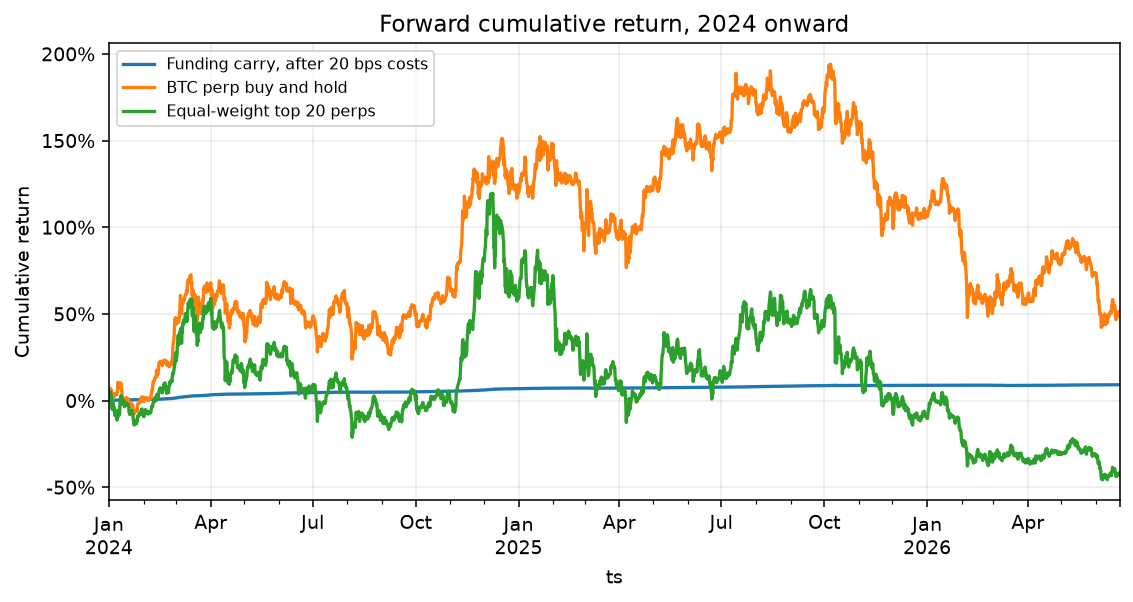

In [ ]:
plot_frame = neighborhood.rename(columns={
    'funding_lookback_events': 'lookback',
    'basis_convergence_horizon_events': 'horizon',
})

plt.rcParams.update({'figure.dpi': 140, 'savefig.dpi': 160, 'axes.grid': True, 'grid.alpha': 0.25})

def pct_axis(axis, decimals=0):
    axis.set_major_formatter(lambda value, pos: f'{value:.{decimals}%}')

def save_chart(fig, name):
    fig.tight_layout()
    fig.savefig(CHARTS / name)
    plt.close(fig)
    return fig

forward_index = net.loc[FORWARD_START:].index
cumulative = pd.DataFrame({
    'Funding carry, after 20 bps costs': (1 + net.reindex(forward_index).fillna(0.0)).cumprod() - 1,
    'BTC perp buy and hold': (1 + perp_ret['BTC'].reindex(forward_index).fillna(0.0)).cumprod() - 1,
    'Equal-weight top 20 perps': (1 + perp_ret.mean(axis=1).reindex(forward_index).fillna(0.0)).cumprod() - 1,
})

ax = cumulative.plot(figsize=(8.2, 4.4), linewidth=1.7)
ax.set(title='Forward cumulative return, 2024 onward', ylabel='Cumulative return')
pct_axis(ax.yaxis)
ax.legend(loc='best', fontsize=8)

fig = save_chart(ax.figure, 'forward_cumulative_returns.png')
fig

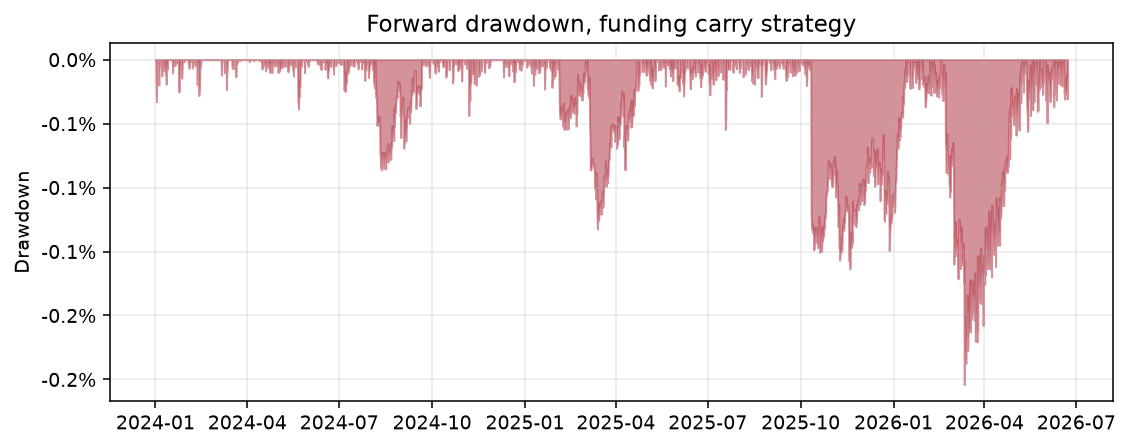

In [126]:
wealth = (1 + net.reindex(forward_index).fillna(0.0)).cumprod()
drawdown = wealth / wealth.cummax() - 1

fig, ax = plt.subplots(figsize=(8.2, 3.3))
ax.fill_between(drawdown.index, drawdown.values, 0, color='#b23a48', alpha=0.55)
ax.set(title='Forward drawdown, funding carry strategy', ylabel='Drawdown')
pct_axis(ax.yaxis, 1)

fig = save_chart(fig, 'forward_drawdown.png')
fig

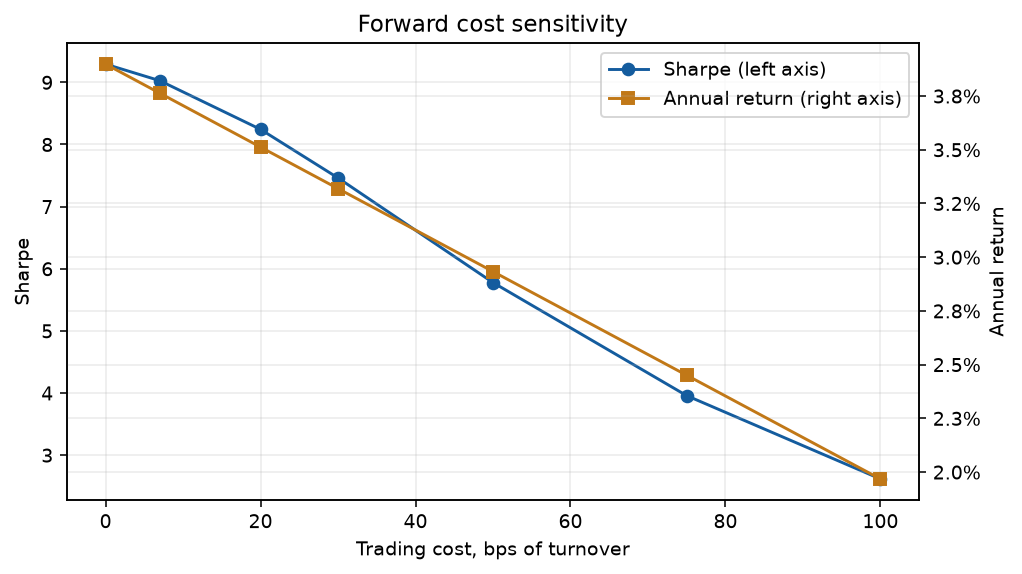

In [127]:
forward_costs = cost_sensitivity[cost_sensitivity['sample'].eq('forward_2024_onward')]

fig, ax1 = plt.subplots(figsize=(7.4, 4.2))
line1 = ax1.plot(forward_costs['cost_bps'], forward_costs['sharpe'], marker='o', color='#145c9e', label='Sharpe (left axis)')
ax1.set(title='Forward cost sensitivity', xlabel='Trading cost, bps of turnover', ylabel='Sharpe')
ax2 = ax1.twinx()
line2 = ax2.plot(forward_costs['cost_bps'], forward_costs['annual_return'], marker='s', color='#c17817', label='Annual return (right axis)')
ax2.set_ylabel('Annual return')
pct_axis(ax2.yaxis, 1)
lines = line1 + line2
ax1.legend(lines, [line.get_label() for line in lines], loc='upper right', frameon=True)

fig = save_chart(fig, 'cost_sensitivity.png')
fig

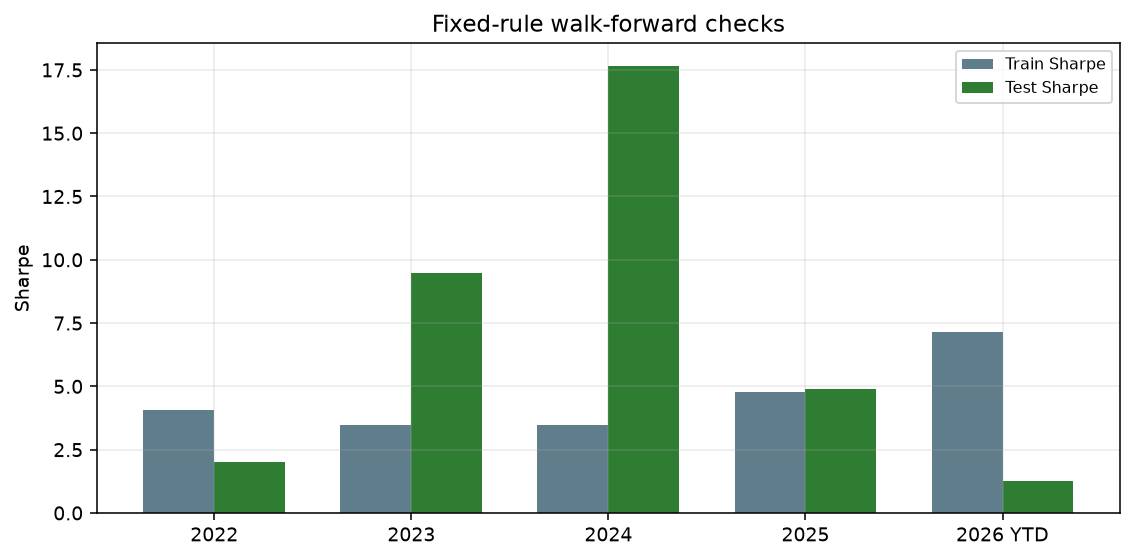

In [128]:
fig, ax = plt.subplots(figsize=(8.2, 4.1))
x = np.arange(len(walk_forward))
ax.bar(x - 0.18, walk_forward['train_sharpe'], width=0.36, label='Train Sharpe', color='#607d8b')
ax.bar(x + 0.18, walk_forward['test_sharpe'], width=0.36, label='Test Sharpe', color='#2e7d32')
ax.set(title='Fixed-rule walk-forward checks', ylabel='Sharpe', xticks=x, xticklabels=['2022', '2023', '2024', '2025', '2026 YTD'])
ax.legend(fontsize=8)

fig = save_chart(fig, 'walk_forward_sharpe.png')
fig

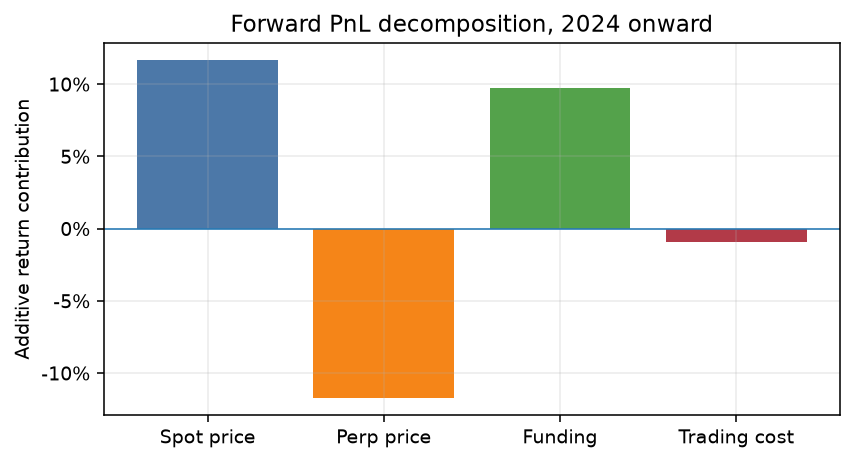

In [129]:
pnl_cols = {
    'spot_price_sum': 'Spot price',
    'perp_price_sum': 'Perp price',
    'funding_cashflow_sum': 'Funding',
    'cost_sum': 'Trading cost',
}

forward_pnl = (
    pnl_decomposition
    .set_index('sample')
    .loc['forward_2024_onward', list(pnl_cols)]
    .rename(index=pnl_cols)
)

fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.bar(forward_pnl.index, forward_pnl.values, color=['#4c78a8', '#f58518', '#54a24b', '#b23a48'])
ax.axhline(0, linewidth=0.8)
ax.set(title='Forward PnL decomposition, 2024 onward', xlabel='', ylabel='Additive return contribution')
pct_axis(ax.yaxis)
ax.tick_params(axis='x', rotation=0)

fig = save_chart(fig, 'pnl_decomposition.png')
fig

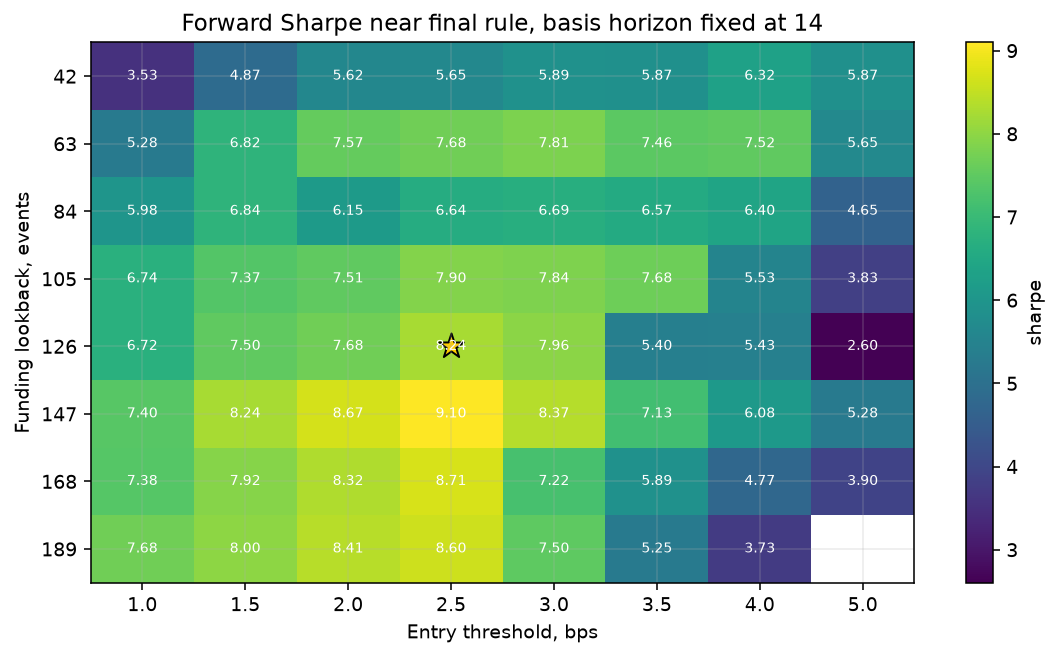

In [142]:
def heatmap(frame, sample, value, fixed_col, fixed_value, y_col, title, file_name, cmap='viridis'):
    subset = frame[frame['sample'].eq(sample) & frame[fixed_col].eq(fixed_value)]
    pivot = subset.pivot_table(index=y_col, columns='open_threshold', values=value).sort_index()
    values = pivot.to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(8.2, 4.8))
    image = ax.imshow(values, aspect='auto', cmap=cmap)
    ax.set(title=title, xlabel='Entry threshold, bps', ylabel='Funding lookback, events' if y_col == 'lookback' else 'Basis horizon, events')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'{x * 10_000:.1f}' for x in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([str(x) for x in pivot.index])

    for row, col in product(range(values.shape[0]), range(values.shape[1])):
        if np.isfinite(values[row, col]):
            ax.text(col, row, f'{values[row, col]:.2f}', ha='center', va='center', color='white', fontsize=7)

    final_y = FINAL_LOOKBACK if y_col == 'lookback' else FINAL_HORIZON
    if final_y in pivot.index and FINAL_ENTRY in pivot.columns:
        ax.scatter(pivot.columns.get_loc(FINAL_ENTRY), pivot.index.get_loc(final_y), marker='*', s=180, color='#ffcc00', edgecolor='black')

    fig.colorbar(image, ax=ax, label=value.replace('_', ' '))
    return save_chart(fig, file_name)

fig = heatmap(
    plot_frame,
    'forward_2024_onward',
    'sharpe',
    'horizon',
    FINAL_HORIZON,
    'lookback',
    'Forward Sharpe near final rule, basis horizon fixed at 14',
    'parameter_heatmap_forward_sharpe_lookback_open.png',
)
fig

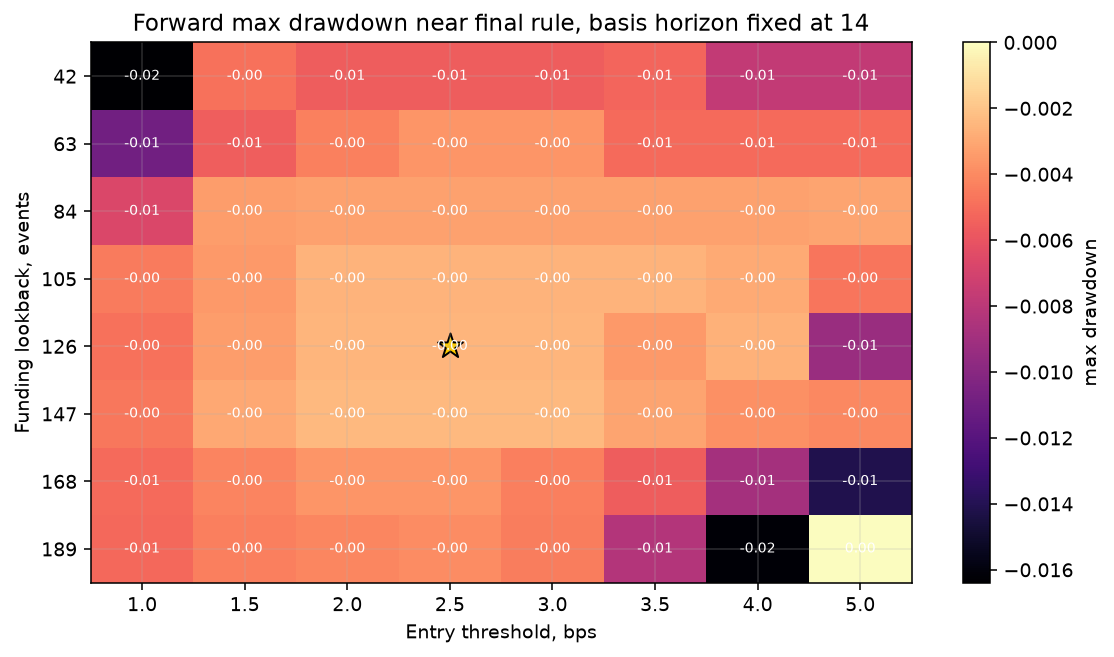

In [140]:
fig = heatmap(
    plot_frame,
    'forward_2024_onward',
    'max_drawdown',
    'horizon',
    FINAL_HORIZON,
    'lookback',
    'Forward max drawdown near final rule, basis horizon fixed at 14',
    'parameter_heatmap_forward_drawdown_lookback_open.png',
    cmap='magma',
)
fig

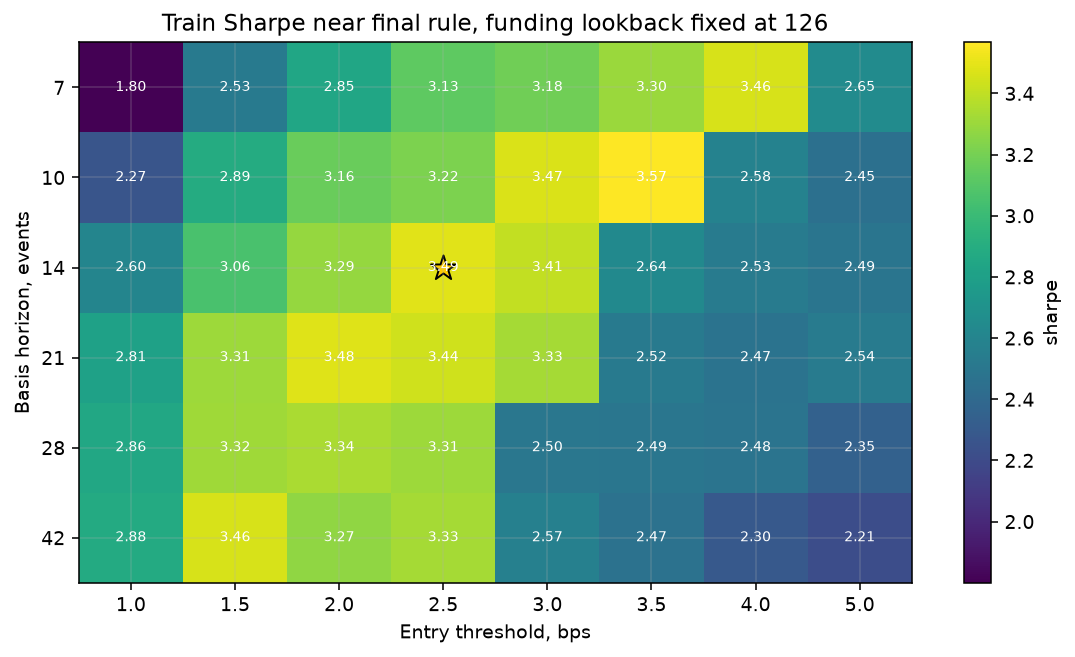

In [139]:
fig = heatmap(
    plot_frame,
    'train_2020_2023',
    'sharpe',
    'lookback',
    FINAL_LOOKBACK,
    'horizon',
    'Train Sharpe near final rule, funding lookback fixed at 126',
    'parameter_heatmap_train_sharpe_horizon_open.png',
)
fig

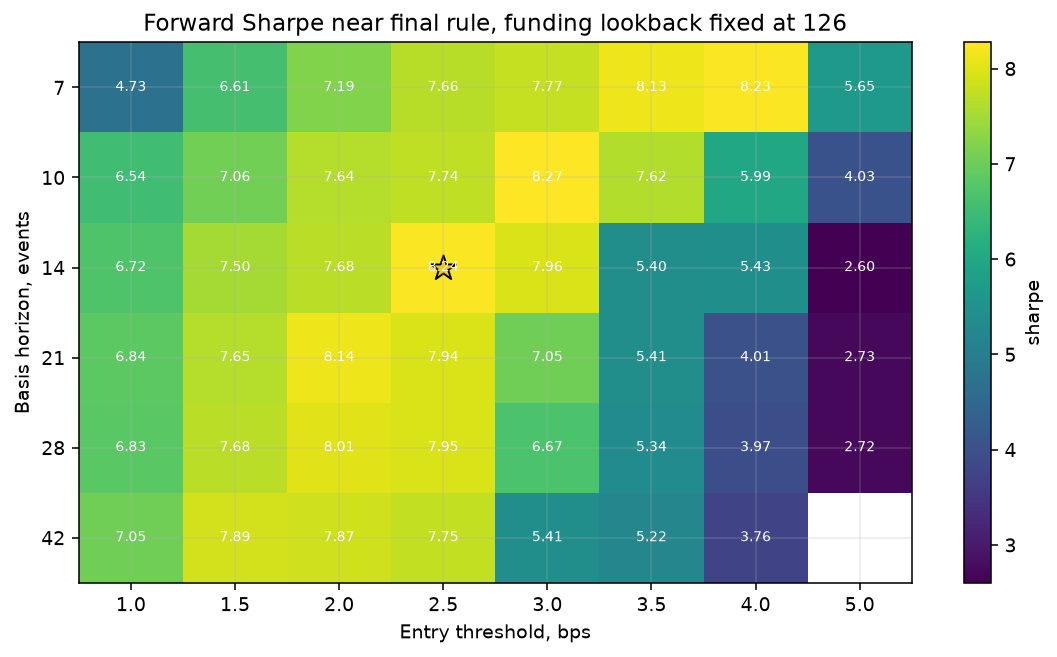

In [138]:
fig = heatmap(
    plot_frame,
    'forward_2024_onward',
    'sharpe',
    'lookback',
    FINAL_LOOKBACK,
    'horizon',
    'Forward Sharpe near final rule, funding lookback fixed at 126',
    'parameter_heatmap_forward_sharpe_horizon_open.png',
)
fig

## 9. Final Sanity Check


In [137]:
assert checks['status'].eq('PASS').all(), checks

sample_metrics.loc[
    sample_metrics['sample'].isin(['train_2020_2023', 'forward_2024_onward']),
    ['sample', 'annual_return', 'annual_volatility', 'sharpe', 'total_return', 'max_drawdown'],
]

,sample,annual_return,annual_volatility,sharpe,total_return,max_drawdown
0,train_2020_2023,0.0729,0.0209,3.4864,0.3377,-0.0264
1,forward_2024_onward,0.0351,0.0043,8.2434,0.0908,-0.0025
